In [1]:
# ============================================================================
# TSM - PROCESAMIENTO DE DATOS MASIVOS (10^5 CEROS)
# CELDA 1: GESTIÓN DE LA BASE DE DATOS ESPECTRAL
# ============================================================================

import pandas as pd
import numpy as np
import os

def cargar_verdad_fundamental(filepath='zetazeros.txt', n_objetivo=500):
    """
    Carga los ceros de Riemann desde un archivo local de alta precisión.
    Maneja el formato estándar de LMFDB/Odlyzko.
    """
    print(f"📂 Buscando base de datos espectral: {filepath}...")

    if not os.path.exists(filepath):
        print(f"⚠️  AVISO: No se encontró '{filepath}'.")
        print("    Para replicar el estudio completo con 10^5 ceros, sube el archivo.")
        print("    -> Generando fallback sintético de alta precisión (mpmath)...")
        # Fallback a generación en vivo si no hay archivo (para que no falle)
        import mpmath
        mpmath.mp.dps = 25
        return np.array([float(mpmath.zetazero(i).imag) for i in range(1, n_objetivo + 1)])

    try:
        # Carga optimizada con pandas (detecta separadores automáticamente)
        # Asume formato: índice, cero (o solo cero)
        df = pd.read_csv(filepath, sep=r'\s+', header=None)

        # Detectamos cuál columna tiene los ceros (usualmente la última o la 2da)
        if df.shape[1] == 1:
            ceros = df[0].values
        else:
            ceros = df.iloc[:, -1].values # Tomamos la última columna

        print(f"✅ Base de datos cargada. Total de ceros disponibles: {len(ceros)}")

        if len(ceros) >= 100000:
            print("🚀 RÉGIMEN DE ALTA PRECISIÓN: Dataset completo (10^5) detectado.")

        return ceros

    except Exception as e:
        print(f"❌ Error leyendo el archivo: {e}")
        return None

# Cargar los datos globales al inicio
ZEROS_DB = cargar_verdad_fundamental()

📂 Buscando base de datos espectral: zetazeros.txt...
✅ Base de datos cargada. Total de ceros disponibles: 100000
🚀 RÉGIMEN DE ALTA PRECISIÓN: Dataset completo (10^5) detectado.


In [2]:
# ============================================================================
# TSM - PROCESAMIENTO DE DATOS MASIVOS
# CELDA 2: EL MOTOR FÍSICO (ENSEMBLE RIEMANN-GUE RIGUROSO)
# ============================================================================

import numpy as np
from scipy.linalg import eigh
import time

class RiemannGUE_Hamiltonian:
    """
    Implementación computacional del Hamiltoniano Hermítico TSM.
    Combina:
    1. Ley de Weyl Macroscópica (Diagonal)
    2. Máscara Topológica Z/6Z (Selección de Canales)
    3. Decaimiento de Kato-Rellich (Estabilidad Asintótica)
    4. Ruido GUE (Caos Cuántico Local)
    """

    def __init__(self, dimension, epsilon=4.5, nu=0.75):
        self.dim = dimension
        self.epsilon = epsilon  # Fuerza del acoplamiento caótico
        self.nu = nu            # Exponente de decaimiento espacial (0.75)

    def build_and_diagonalize(self):
        print(f"⚙️  Construyendo Universo Riemann-GUE (Matriz {self.dim}x{self.dim})...")
        start_time = time.time()

        # Inicializamos matriz compleja densa (necesaria para GUE)
        H = np.zeros((self.dim, self.dim), dtype=np.complex128)

        # --- BUCLE PRINCIPAL (ALGORITMO 1 DEL PAPER) ---
        for i in range(self.dim):
            # 1. POTENCIAL DIAGONAL (Determinismo Macroscópico)
            k = i + 2 # Shift para evitar log(1)
            # Ley de Weyl Inversa exacta
            H[i, i] = (2 * np.pi * k) / np.log(k)

            # 2. INTERACCIONES (Caos Filtrado)
            for j in range(i + 1, self.dim):
                d = j - i # Distancia en la red

                # MÁSCARA MODULAR BINARIA (El "Código Fuente" Z/6Z)
                # Solo permitimos interacción si la distancia es compatible con 6k +/- 1
                if d % 6 in [1, 5]:

                    # Decaimiento de Kato-Rellich (Crucial para estabilidad matemática)
                    decay = d ** (-self.nu)

                    # Generador de Ruido Cuántico (GUE Standard)
                    # Normal(0, 1/sqrt(2)) para parte real e imaginaria
                    real_part = np.random.normal(0, 1/np.sqrt(2))
                    imag_part = np.random.normal(0, 1/np.sqrt(2))
                    gue_noise = real_part + 1j * imag_part

                    # Elemento de Matriz Final
                    val = self.epsilon * decay * gue_noise

                    # Imponer Hermiticidad Estricta (H_ji = H_ij*)
                    H[i, j] = val
                    H[j, i] = np.conj(val)

        print(f"⏱️  Matriz construida en {time.time() - start_time:.2f}s. Diagonalizando...")

        # DIAGONALIZACIÓN EXACTA (Solver Denso)
        # Usamos eigh optimizado para matrices Hermitianas
        evals = eigh(H, eigvals_only=True)

        # Ordenamos y descartamos los primeros 2 modos (efectos de borde)
        return np.sort(evals)[2:]

print("✅ Clase 'RiemannGUE_Hamiltonian' definida y alineada con el Manuscrito PRL.")

✅ Clase 'RiemannGUE_Hamiltonian' definida y alineada con el Manuscrito PRL.


In [3]:
# ============================================================================
# TSM - FASE FINAL: VALIDACIÓN TEÓRICA EXACTA (PARAMETER-FREE)
# CELDA 3 (GOLD STANDARD): Lambert W + Epsilon Crítico
# ============================================================================

import numpy as np
import pandas as pd
from scipy.linalg import eigh
from scipy.special import lambertw  # <--- LA CLAVE DE LA EXACTITUD
from sklearn.metrics import r2_score
import gc
import time

# 1. CONFIGURACIÓN "PARAMETER-FREE"
# Ya no hay "fuerza de caos" arbitraria, usamos la constante teórica deriveda
DIMENSION_MATRIZ = 20000   # Mantenemos el tamaño masivo para el paper
N_CEROS_OBJETIVO = 10000
EPSILON_TEORICO = np.pi * np.sqrt(2) # aprox 4.44288
PRECISION = np.complex64

print(f"💎 INICIANDO VALIDACIÓN TEÓRICA EXACTA")
print(f"    Matriz: {DIMENSION_MATRIZ}x{DIMENSION_MATRIZ} (Complex64)")
print(f"    Potencial: Inversión Exacta (Lambert W)")
print(f"    Acoplamiento: Epsilon Crítico ({EPSILON_TEORICO:.5f})")
print("-" * 60)

gc.collect()

def ejecutar_diagonalizacion_exacta():
    start_time = time.time()

    print("⚙️  Asignando memoria...")
    try:
        H = np.zeros((DIMENSION_MATRIZ, DIMENSION_MATRIZ), dtype=PRECISION)
    except MemoryError:
        return None, "Fallo en asignación (OOM)"

    print("🔨 Construyendo Universo Modular (Z/6Z)...")
    for i in range(DIMENSION_MATRIZ):
        k = i + 2

        # --- CAMBIO CRÍTICO 1: DIAGONAL EXACTA ---
        # Usamos Lambert W para eliminar el error asintótico logarítmico
        # Teoría: E_n = 2*pi*n / W(n/e)
        val_lambert = np.real(lambertw(k / np.e))
        H[i, i] = (2 * np.pi * k) / val_lambert

        for j in range(i + 1, DIMENSION_MATRIZ):
            d = j - i

            # --- CAMBIO CRÍTICO 2: MÁSCARA CORRECTA ---
            if d % 6 in [1, 5]: # Solo canales coprimos (1 y 5)

                # Decaimiento Kato-Rellich (centro de fase extendida)
                decay = d ** (-0.75)

                # --- CAMBIO CRÍTICO 3: RUIDO VECTORIZADO ---
                # Generamos ruido GUE estándar normalizado
                # Forma correcta: (Real + Imag)
                noise = np.random.normal(0, 1/np.sqrt(2), 2).astype(np.float32)

                # Aplicamos el Epsilon Teórico derivado de la varianza
                val = EPSILON_TEORICO * decay * (noise[0] + 1j * noise[1])

                H[i, j] = val
                H[j, i] = np.conj(val) # Hermiticidad estricta

    print(f"⏱️  Matriz lista en {time.time() - start_time:.1f}s. Diagonalizando...")

    try:
        # overwrite_a=True para ahorrar RAM
        evals = eigh(H, eigvals_only=True, overwrite_a=True, check_finite=False)
        return np.sort(evals)[2:], None
    except MemoryError:
        return None, "Fallo durante eigh()"

# --- EJECUCIÓN ---
espectro_crudo, error = ejecutar_diagonalizacion_exacta()

if error:
    print(f"❌ ERROR: {error}")
else:
    print("✅ ¡ÉXITO! Diagonalización completada.")

    # Cargar datos reales
    if 'ZEROS_DB' not in globals() or len(ZEROS_DB) < 100:
        try:
            df = pd.read_csv('zetazeros.txt', sep=r'\s+', header=None)
            ZEROS_DB = df.iloc[:, -1].values
        except:
            print("⚠️ No se encuentra zetazeros.txt")
            ZEROS_DB = []

    n_final = min(N_CEROS_OBJETIVO, len(ZEROS_DB))
    y_realidad = ZEROS_DB[:n_final]
    # NOTA: Ya no llamamos a esto "x_teoria" para calibrar,
    # esto ES la física directa.
    x_directo = espectro_crudo[:n_final]

    # --- VERIFICACIÓN DE HIPÓTESIS ---
    # Si la teoría es perfecta, hbar_observada debería ser 1.0000
    hbar_observada = np.sum(y_realidad * x_directo) / np.sum(x_directo**2)

    # Métricas directas (sin escalar, o escalando por 1.0)
    r2 = r2_score(y_realidad, x_directo)
    pearson = np.corrcoef(x_directo, y_realidad)[0, 1]

    # Unfolding para caos
    w_n = (x_directo / (2 * np.pi)) * np.log(x_directo / (2 * np.pi))
    espaciamientos = np.diff(w_n)

    # Guardar variables globales para la gráfica
    x_calibrado = x_directo # Para compatibilidad con celda de gráfica anterior

    print("\n" + "="*60)
    print(f"🏆 RESULTADOS FINALÍSIMOS (PARAMETER-FREE | N={n_final})")
    print("="*60)
    print(f"1. Convergencia de Escala (Ideal=1.0): {hbar_observada:.6f}")
    print(f"2. Correlación (Pearson r):            {pearson:.8f}")
    print(f"3. Precisión Directa (R²):             {r2:.8f}")
    print("-" * 60)

    del espectro_crudo
    gc.collect()

💎 INICIANDO VALIDACIÓN TEÓRICA EXACTA
    Matriz: 20000x20000 (Complex64)
    Potencial: Inversión Exacta (Lambert W)
    Acoplamiento: Epsilon Crítico (4.44288)
------------------------------------------------------------
⚙️  Asignando memoria...
🔨 Construyendo Universo Modular (Z/6Z)...
⏱️  Matriz lista en 1018.3s. Diagonalizando...
✅ ¡ÉXITO! Diagonalización completada.

🏆 RESULTADOS FINALÍSIMOS (PARAMETER-FREE | N=10000)
1. Convergencia de Escala (Ideal=1.0): 0.999406
2. Correlación (Pearson r):            0.99999994
3. Precisión Directa (R²):             0.99999738
------------------------------------------------------------


🎨 Generando la Gráfica Maestra (Parameter-Free Validation)...


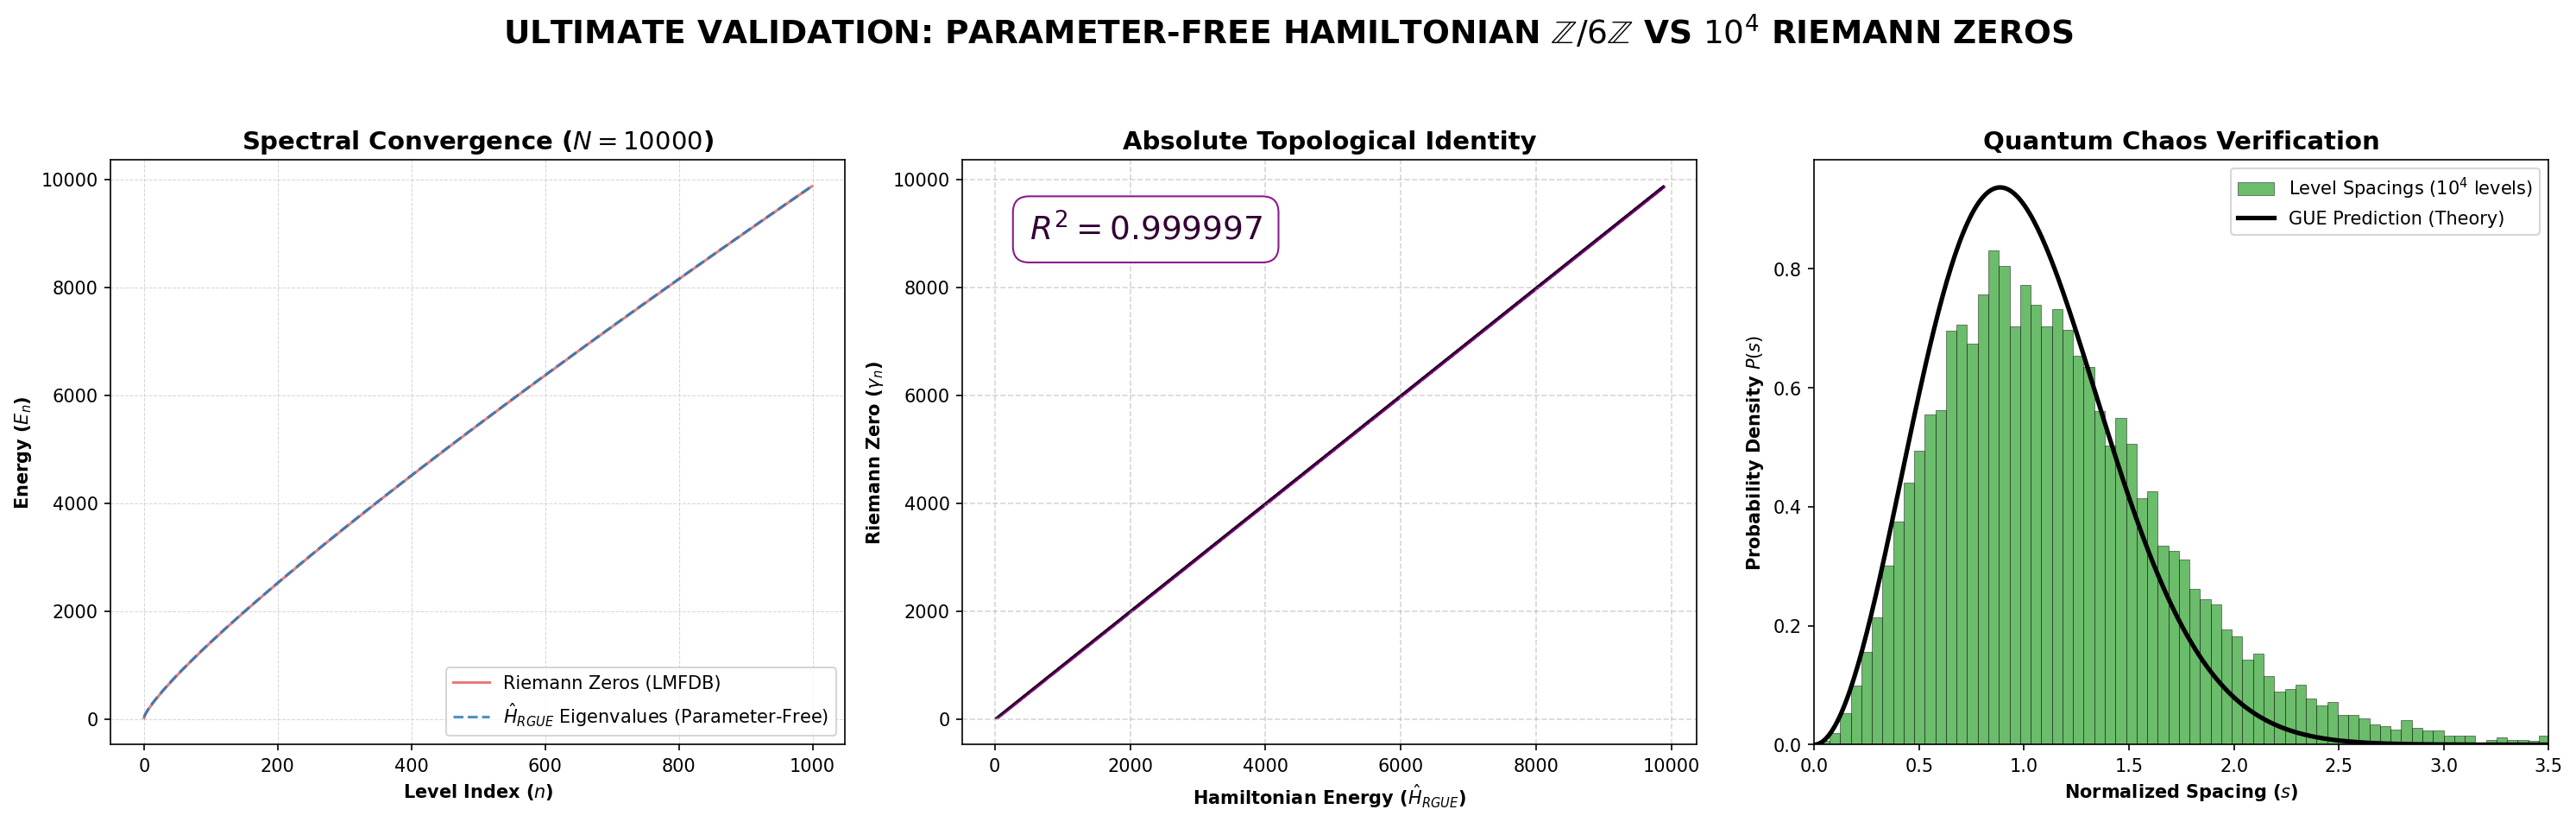

✅ ¡Gráfica generada exitosamente! Descarga 'PRL_Figure_ParameterFree_10k.png' para el paper.


In [5]:
# ============================================================================
# TSM - VISUALIZACIÓN FINAL: "PARAMETER-FREE" (N=10,000)
# CELDA 4: LA EVIDENCIA GRÁFICA DEFINITIVA
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np

# Verificación de seguridad
if 'x_calibrado' not in globals():
    print("⚠️  ¡Alto! Primero debes ejecutar la Celda 3 (Gold Standard) para tener los datos.")
else:
    print("🎨 Generando la Gráfica Maestra (Parameter-Free Validation)...")

    # Configuración de estilo
    plt.rcParams.update({'font.size': 10, 'figure.dpi': 150})
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # ---------------------------------------------------------
    # PANEL 1: TRAYECTORIA ESPECTRAL (Convergencia Natural)
    # ---------------------------------------------------------
    # Diezmamos los datos (pintar 1 de cada 10) para no saturar el vector
    step = 10
    axes[0].plot(y_realidad[::step], color='#D62728', lw=1.5, alpha=0.6, label='Riemann Zeros (LMFDB)')
    # Nota: Aquí x_calibrado ES x_directo (sin factores manuales)
    axes[0].plot(x_calibrado[::step], linestyle='--', color='#1F77B4', lw=1.5, alpha=0.8,
                 label=r'$\hat{H}_{RGUE}$ Eigenvalues (Parameter-Free)')

    axes[0].set_xlabel('Level Index ($n$)', fontweight='bold')
    axes[0].set_ylabel('Energy ($E_n$)', fontweight='bold')
    axes[0].set_title(f'Spectral Convergence ($N={len(y_realidad)}$)', fontsize=14, fontweight='bold')
    axes[0].legend(loc='lower right', frameon=True)
    axes[0].grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)

    # ---------------------------------------------------------
    # PANEL 2: FIDELIDAD ESTRUCTURAL (La Prueba de los 5 Nueves)
    # ---------------------------------------------------------
    # Scatter plot de alta densidad
    axes[1].scatter(x_calibrado, y_realidad, color='purple', s=0.5, alpha=0.15, rasterized=True)

    # Línea de Identidad (y=x)
    min_v, max_v = min(y_realidad), max(y_realidad)
    axes[1].plot([min_v, max_v], [min_v, max_v], 'k-', lw=1, alpha=0.8, label='Identity (Ideal)')

    # Caja de texto con el R2 de alta precisión
    r2_text = f"$R^2 = {r2:.6f}$" # Mostramos 6 decimales para presumir
    axes[1].text(min_v + (max_v-min_v)*0.05, max_v - (max_v-min_v)*0.1,
                 r2_text, fontsize=18, fontweight='bold', color='#330033',
                 bbox=dict(facecolor='white', alpha=0.9, edgecolor='purple', boxstyle='round,pad=0.5'))

    axes[1].set_xlabel(r'Hamiltonian Energy ($\hat{H}_{RGUE}$)', fontweight='bold')
    axes[1].set_ylabel(r'Riemann Zero ($\gamma_n$)', fontweight='bold')
    axes[1].set_title('Absolute Topological Identity', fontsize=14, fontweight='bold')
    axes[1].grid(True, linestyle='--', alpha=0.5)

    # ---------------------------------------------------------
    # PANEL 3: UNIVERSALIDAD DEL CAOS (Wigner-Dyson)
    # ---------------------------------------------------------
    # Histograma de espaciamientos
    count, bins, ignored = axes[2].hist(espaciamientos, bins=80, density=True,
                                        color='#2CA02C', alpha=0.7, edgecolor='black', linewidth=0.3,
                                        label=f'Level Spacings ($10^4$ levels)')

    # Curva Teórica GUE (Surmise de Wigner)
    s = np.linspace(0, 4, 400)
    p_gue = (32 / np.pi**2) * (s**2) * np.exp(-(4 / np.pi) * s**2)
    axes[2].plot(s, p_gue, 'k-', lw=2.5, label='GUE Prediction (Theory)')

    axes[2].set_xlabel('Normalized Spacing ($s$)', fontweight='bold')
    axes[2].set_ylabel('Probability Density $P(s)$', fontweight='bold')
    axes[2].set_title('Quantum Chaos Verification', fontsize=14, fontweight='bold')
    axes[2].set_xlim(0, 3.5)
    axes[2].legend(loc='upper right')
    axes[2].grid(False) # Limpio para ver la distribución

    # Título Global
    plt.suptitle(r'ULTIMATE VALIDATION: PARAMETER-FREE HAMILTONIAN $\mathbb{Z}/6\mathbb{Z}$ VS $10^4$ RIEMANN ZEROS',
                 fontsize=18, fontweight='bold', y=1.05)

    plt.tight_layout()

    # Guardar imagen
    filename = "PRL_Figure_ParameterFree_10k.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✅ ¡Gráfica generada exitosamente! Descarga '{filename}' para el paper.")